# Customer Churn Prediction using Scikit-learn Pipeline

## 1. Problem Statement
The goal of this project is to build a reusable and production-ready machine learning pipeline to predict customer churn using the Telco Churn dataset.

## 2. Dataset Loading and Exploration

## 3. Data Preprocessing

## 4. Building ML Pipelines

## 5. Model Training and Hyperparameter Tuning

## 6. Model Evaluation

## 7. Model Comparison

## 8. Saving the Best Pipeline

## 9. Final Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape of dataset: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents  

In [4]:
# Remove customerID because it is just an identifier
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values again
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [5]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [7]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (5634, 19)
Test set shape: (1409, 19)


In [10]:
log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [11]:
log_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["liblinear", "lbfgs"]
}

log_grid = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", log_grid.best_params_)
print("Best CV Score:", log_grid.best_score_)

Best Logistic Regression Parameters: {'classifier__C': 10, 'classifier__solver': 'liblinear'}
Best CV Score: 0.598941254378938


In [12]:
best_log_model = log_grid.best_estimator_
y_pred_log = best_log_model.predict(X_test)
y_proba_log = best_log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.8048261178140526
Precision: 0.6551724137931034
Recall: 0.5588235294117647
F1-score: 0.6031746031746031
ROC-AUC: 0.8411235113281149

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



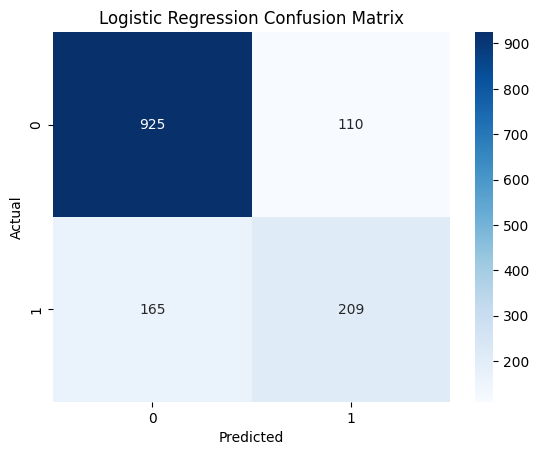

In [13]:
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

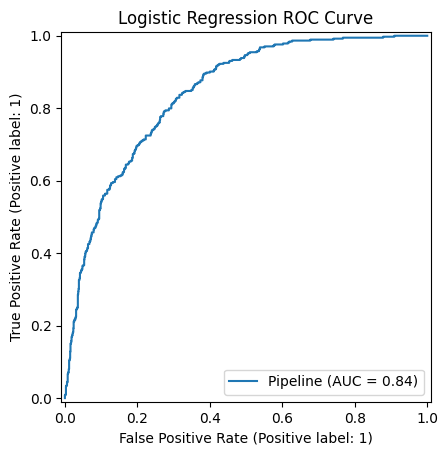

In [14]:
RocCurveDisplay.from_estimator(best_log_model, X_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()

In [15]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [16]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV Score: 0.582317849363679


In [18]:
best_rf_model = rf_grid.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7998580553584103
Precision: 0.6564625850340136
Recall: 0.516042780748663
F1-score: 0.5778443113772455
ROC-AUC: 0.8385452995427419

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



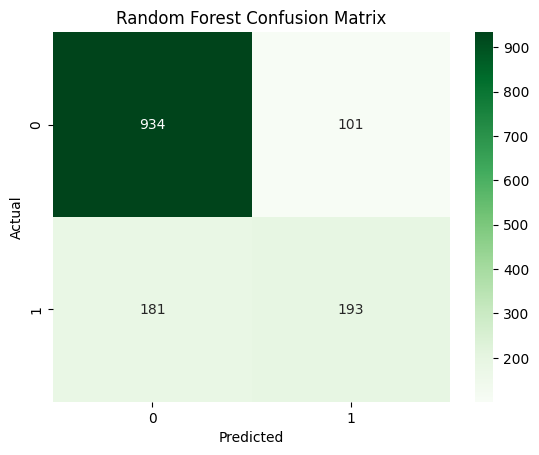

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

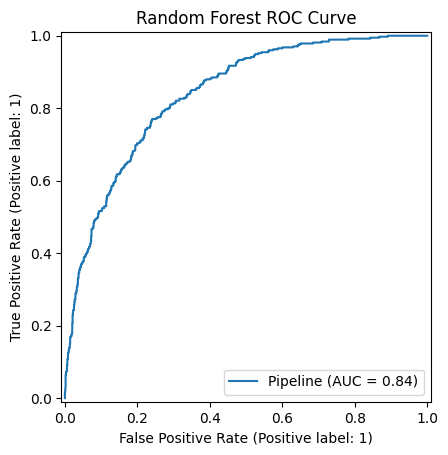

In [20]:
RocCurveDisplay.from_estimator(best_rf_model, X_test, y_test)
plt.title("Random Forest ROC Curve")
plt.show()

In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804826,0.655172,0.558824,0.603175,0.841124
1,Random Forest,0.799858,0.656463,0.516043,0.577844,0.838545


In [22]:
if f1_score(y_test, y_pred_log) > f1_score(y_test, y_pred_rf):
    best_model = best_log_model
    best_model_name = "logistic_regression_pipeline.pkl"
else:
    best_model = best_rf_model
    best_model_name = "random_forest_pipeline.pkl"

joblib.dump(best_model, best_model_name)
print(f"Best model saved as: {best_model_name}")

Best model saved as: logistic_regression_pipeline.pkl


In [23]:
loaded_model = joblib.load(best_model_name)

sample_prediction = loaded_model.predict(X_test.iloc[:5])
sample_probability = loaded_model.predict_proba(X_test.iloc[:5])

print("Predictions:", sample_prediction)
print("Probabilities:\n", sample_probability)

Predictions: [0 1 0 0 0]
Probabilities:
 [[0.95259594 0.04740406]
 [0.31740589 0.68259411]
 [0.94998757 0.05001243]
 [0.57736927 0.42263073]
 [0.97707134 0.02292866]]


In [24]:
print("""
Summary:
- Built an end-to-end ML pipeline for customer churn prediction.
- Applied preprocessing using Pipeline and ColumnTransformer.
- Trained Logistic Regression and Random Forest models.
- Tuned hyperparameters using GridSearchCV.
- Evaluated models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Exported the best-performing pipeline using joblib for reuse in production.
""")


Summary:
- Built an end-to-end ML pipeline for customer churn prediction.
- Applied preprocessing using Pipeline and ColumnTransformer.
- Trained Logistic Regression and Random Forest models.
- Tuned hyperparameters using GridSearchCV.
- Evaluated models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Exported the best-performing pipeline using joblib for reuse in production.

